In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
# import os
# import sys
# import architecture
import FCYeast2_simulator
import torch
device='cpu'

/home/pessoa/Codes/SBI-Final/FC-inference/FCYeast2/FCYeast_simulator.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autofluo.load_state_dict(torch.load('autofluorescen

In [2]:
g3 = np.loadtxt('FCYeast2_MCMC/mcmc_real_results_42seed_116224datapoints.csv')[:,:]
map_index = np.argmax(g3[:,-1])
best_param = torch.tensor(g3[map_index]).float().to(device)
best_param


tensor([ 1.3084e+01, -2.1374e-01,  2.4594e+00, -2.8295e+00, -2.2792e+00,
         1.3158e+00, -3.6246e+00, -3.2845e+05])

In [3]:
FCYeast2_simulator.adjust_device(device)
target = FCYeast2_simulator.FCYeast_simulator.target()

def grid_plot(x,param,model,log10 = False):
    xp = torch.linspace(x.min(),x.max(),101).to(device)
    print(xp.type(),param.type(),torch.ones((101,4),device=device).type())
    lp = model.log_prob(xp.reshape(-1,1),torch.ones((101,4),device=device)*param)
    p = torch.exp(lp-lp.max())
    p *= 1/(p.sum()*(xp[1]-xp[0]))
    if log10:
        l10 = 2.302585
        return xp.cpu()/l10,p.cpu()*l10
    return xp.cpu(),p.cpu()



Text(0.5, 0, 'Fracton of time in active state')

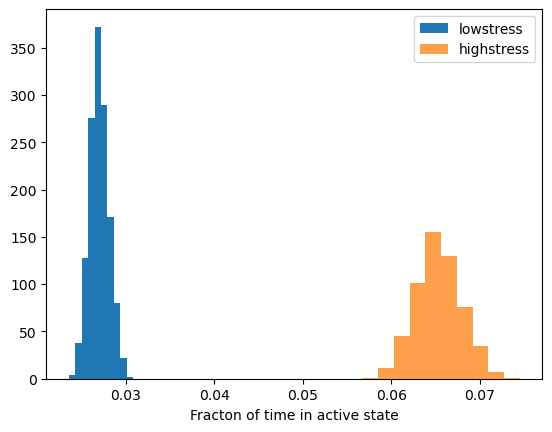

In [4]:
lact = np.exp(g3[-100000:,4])
lina = np.exp(g3[-100000:,5])
frac = lact/(lact+lina)
plt.hist(frac,label = 'lowstress',density=True)

lact = np.exp(g3[-100000:,1])
lina = np.exp(g3[-100000:,2])
frac = lact/(lact+lina)
plt.hist(frac,label = 'highstress',alpha=.75,density=True)

plt.legend()
plt.xlabel('Fracton of time in active state')

In [5]:
torch.exp(FCYeast2_simulator.transform_to_arbitrary((best_param)))

tensor([[4.0104e+06, 8.0756e-01, 1.1698e+01, 5.9044e-02],
        [2.0924e+06, 1.0237e-01, 3.7279e+00, 2.6659e-02]])

In [6]:
mos = [['X' ,'X' ,'lact1','lina1','sig1'],
       ['bh','bh','lact1','lina1','sig1'],
       ['bh','bh','lact2','lina2','sig2'],
       ['X' ,'X' ,'lact2','lina2','sig2']]

moA = [['bh1','lact1','lina1','sig1'],
       ['bh2','lact2','lina2','sig2']]

In [7]:
dils = [.12,.23]

def separate(x):
    return np.array(((x[0],x[1],x[2],x[3]),
                     (x[0],x[4],x[5],x[6])))

to_hours = -np.array(((0,-1,-1,1),
                     (0,-1,-1,1)))*np.log(dils).reshape(-1,1)

def transform_to_hour(x): #suppose that \betas (0 and 1) are in hours, and the other in the arbirary units. Turn them all in hours
    return separate(x) + to_hours


to_arbitrary = -np.array(((1, 0, 0, 0),
                          (1, 0, 0, 0)))*np.log(dils).reshape(-1,1)

def transform_to_arbitrary(x):  #suppose that \betas (0 and 1) are in hours, and the other in the arbirary units. Turn them all to arbitrary
    return separate(x) + to_arbitrary

def separate_sampled_par(sampled_par):
    ld1,ld2,ld3 = [],[],[]
    for sp in sampled_par:
        sp_sep = transform_to_hour(sp)
        #sp_sep=separate(sp)
        for (spi,ld) in zip(sp_sep,(ld1,ld2)):
            ld.append(1.0*spi)

    return np.stack(ld1),np.stack(ld2)

def separate_sampled_arb(sampled_par):
    ld1,ld2,ld3 = [],[],[]
    for sp in sampled_par:
        sp_sep = transform_to_arbitrary(sp)

        for (spi,ld) in zip(sp_sep,(ld1,ld2)):
            ld.append(1.0*spi)

    return np.stack(ld1),np.stack(ld2)

In [8]:
tranform_fun = {'ln':lambda x:x,
                'log10': lambda x:x/np.log(10),
                'real': np.exp}
tranform_pre = {'ln': r'$\ln$',
                'log10': r'$\log_{10}$',
                'real': ''}

def make_fig(sampled_par,lp,transform = 'ln',time_scale='real'):
    if time_scale == 'real':
        fig,ax = plt.subplot_mosaic(mos,figsize=(16,6),empty_sentinel='X')
        s1,s2 = separate_sampled_par(sampled_par)
    elif time_scale == 'arbitrary':
        fig,ax = plt.subplot_mosaic(moA,figsize=(16,8))
        s1,s2 = separate_sampled_arb(sampled_par)
    
    

    gr = ['bh','lact1','lina1','sig1']
    lab = [r'$\beta$',r'$\lambda_{act}$',r'$\lambda_{ina}$',r'$\sigma$']

    fun = tranform_fun[transform]
    s1,s2 = fun(s1),fun(s2)
    prelabel = tranform_pre[transform]
    lab = [prelabel + ' ' + l + r' (${h^{-1}}$)' for l in lab]

    gr = ['lact1','lina1','sig1']
    [ax[gr[i]].hist(s1[:,i+1],density=True) for i in range(3)]
    [ax[gr[i]].set_xlabel(lab[i+1] ,fontsize=22) for i in range(3)]
    ax[gr[0]].set_ylabel(r'$\tau ={:.2f} h $ (high stress)'.format((1/dils[0])),fontsize=15)

    gr = ['lact2','lina2','sig2']
    [ax[gr[i]].hist(s2[:,i+1],density=True) for i in range(3)]
    [ax[gr[i]].set_xlabel(lab[i+1] ,fontsize=22) for i in range(3)]
    ax[gr[0]].set_ylabel(r'$\tau ={:.2f} h$ (low stress)'.format((1/dils[1])),fontsize=15)

    if time_scale == 'real':
        ax['bh'].hist(s1[:,0],density=True)
        ax['bh'].set_xlabel(lab[0],fontsize=22)

        # ax['lp'].plot(lp)
        # ax['lp'].axvline(len(lp)-len(sampled_par),color='r')
        # ax['lp'].set_ylim(lp.max()-100,lp.max())
        # ax['lp'].set_ylabel(r'$\log$ posterior')

    elif time_scale == 'arbitrary':
        for (bhi,si) in zip([m[0] for m in moA],(s1,s2)):
            ax[bhi].hist(si[:,0],density=True)
            ax[bhi].set_xlabel(lab[0],fontsize=12)
       

    
    plt.tight_layout()

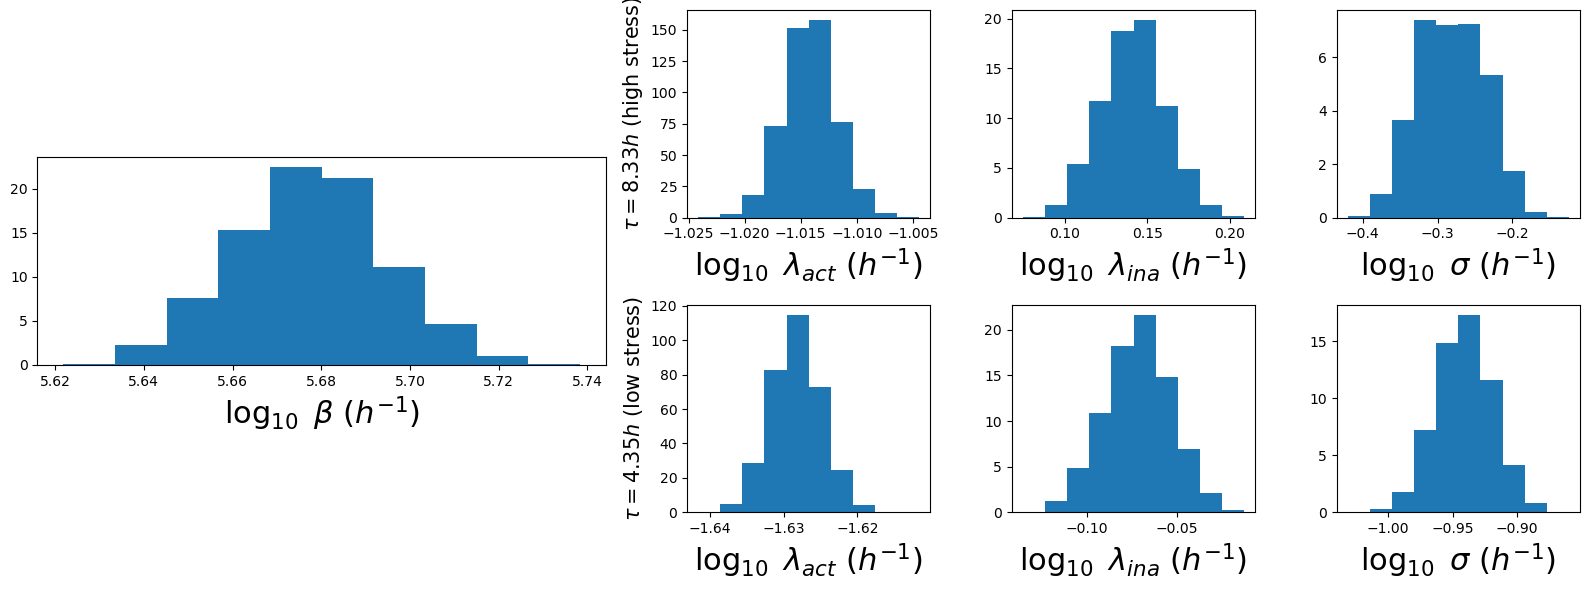

In [9]:
make_fig(g3[-100000:,:-1],g3[-100000:,-1],transform='log10')

In [10]:
s1,s2 = separate_sampled_par(g3)
cols = ['log_10'+ s for s in ['Production rate', 'Activation rate', 'Inactivation rate', 'Cell division variance']]

df1 = pd.DataFrame((s1/np.log(10))[-100000:,:],columns=cols)
df1.to_csv('FCYeast2_MCMC/results_highstress.csv')

df2 = pd.DataFrame((s2/np.log(10))[-100000:,:],columns=cols)
df2.to_csv('FCYeast2_MCMC/results_lowstress.csv')

In [11]:
1/np.array(dils)

array([8.33333333, 4.34782609])

In [12]:
g3[map_index]

array([ 1.30841389e+01, -2.13740364e-01,  2.45940018e+00, -2.82948017e+00,
       -2.27917862e+00,  1.31584537e+00, -3.62464261e+00, -3.28450125e+05])

In [13]:
dt=.1
def forward_run(beta,lina,lact,sig,div_t,mother_only=True):
    div_times = torch.distributions.LogNormal(0., sig).sample((100,)).numpy()
    div_times = div_times[(div_t*div_times)<100]
    sizes = target.rho.sample(div_times.shape).numpy()
    if mother_only:
        sizes = np.maximum(sizes,1-sizes)

    traj_times=[]
    traj_protein=[]
    traj_state=[]

    s= int(np.random.rand()<lina/(lact+lina))

    t=0
    P=0
    for T,newsize in zip(div_times,sizes):
        tin = 0
        while tin<T:
            if s == 1:
                switch_time = np.random.exponential(lina)
                fin_time = min(T,tin+switch_time)
                while tin<fin_time:
                    tin+=dt
                    P+=np.random.poisson(beta*dt)

                    traj_protein.append(P*1)
                    traj_times.append(t+tin*1)
                    traj_state.append(s*1)
                if fin_time!=T:
                    s=0
            else: # s == 0
                switch_time = np.random.exponential(lact)
                if switch_time<T:
                    tin+=switch_time
                    s=1
                else:
                    tin = T


        P = np.random.binomial(P,newsize)
        
        t+=T
        traj_protein.append(P*1)
        traj_times.append(t*1)
        traj_state.append(s*1)
        



    return div_t*np.array(traj_times),np.array(traj_protein)#,np.array(traj_state)


In [14]:
map_arbitrary = [np.exp(arr[map_index]) for arr in separate_sampled_arb(g3)]

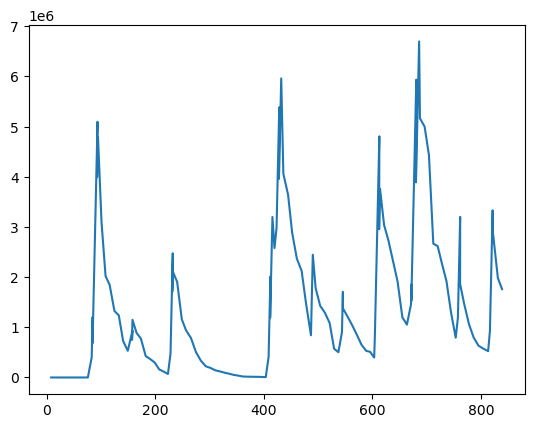

In [15]:
plt.plot(*forward_run(*map_arbitrary[0],1/dils[0]))

In [16]:
1/np.array(dils)

array([8.33333333, 4.34782609])